<a href="https://colab.research.google.com/github/Vronska-Anhelina/Online-store-sales-analytics/blob/main/Online_store_sales_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://public.tableau.com/views/Revenue_17764518435680/Revenue?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

In [1]:
!pip install --upgrade google-cloud-bigquery
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

auth.authenticate_user()
client = bigquery.Client(project="data-analytics-mate")


In [2]:
query = """
SELECT s.date,s.ga_session_id,sp.continent,sp.country,sp.device,sp.browser,sp.name AS model_name,sp.operating_system,sp.language,sp.channel,sp.medium,a.id AS account_id,a.is_verified,a.is_unsubscribed,pr.category,pr.name,pr.price,pr.short_description
   FROM `data-analytics-mate.DA.session` s
LEFT JOIN `DA.session_params` sp
ON s.ga_session_id=sp.ga_session_id
LEFT JOIN `DA.account_session` acs
ON s.ga_session_id=acs.ga_session_id
LEFT JOIN `DA.account` a
ON a.id=acs.account_id
LEFT JOIN `DA.order` o
ON o.ga_session_id=s.ga_session_id
LEFT JOIN `DA.product` pr
ON o.item_id=pr.item_id
"""

query_job = client.query(query)
results = query_job.result()

df = results.to_dataframe()
print(df)

              date  ga_session_id continent        country   device  \
0       2020-11-01      967742695  Americas  United States  desktop   
1       2020-11-01     9065007548      Asia          China  desktop   
2       2020-11-01     3267062634  Americas  United States  desktop   
3       2020-11-01     8892952409  Americas  United States   mobile   
4       2020-11-01     1624570787      Asia         Turkey  desktop   
...            ...            ...       ...            ...      ...   
349540  2021-01-31      830102441  Americas  United States  desktop   
349541  2021-01-31      167350204    Europe         Poland   mobile   
349542  2021-01-31     1587098569  Americas  United States   mobile   
349543  2021-01-31     5756982967    Europe        Ukraine  desktop   
349544  2021-01-31     7058940865    Europe         Norway  desktop   

                browser      model_name operating_system language  \
0                Safari  (data deleted)              Web    en-us   
1        

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   ga_session_id      349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   model_name         349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   channel            349545 non-null  object 
 10  medium             349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  name               33538 non-null   object 
 16  pr

There are 18 columns in the dataset. 5 columns of numeric type (ga_session_id,id,is_verified,is_unsubscribed,price). 12 columns of categorical type, this number includes: continent,country,device,browser,model_name,operating_system,language,channel,medium,category,name,short_description. In the dataframe there is one column of datetime type: date.

In [4]:
unique_sessions = df['ga_session_id'].nunique()
print(f"Unique sessions:{unique_sessions}")
begin=df['date'].min()
end=df['date'].max()
print(f"We consider the following period: {begin}  - {end}")

Unique sessions:349545
We consider the following period: 2020-11-01  - 2021-01-31


In [5]:
print(df.isna().sum())
print(df.isna().sum()/df.shape[0]*100)

date                      0
ga_session_id             0
continent                 0
country                   0
device                    0
browser                   0
model_name                0
operating_system          0
language             114266
channel                   0
medium                    0
account_id           321600
is_verified          321600
is_unsubscribed      321600
category             316007
name                 316007
price                316007
short_description    316007
dtype: int64
date                  0.000000
ga_session_id         0.000000
continent             0.000000
country               0.000000
device                0.000000
browser               0.000000
model_name            0.000000
operating_system      0.000000
language             32.689925
channel               0.000000
medium                0.000000
account_id           92.005321
is_verified          92.005321
is_unsubscribed      92.005321
category             90.405241
name              

Missing values ​​are in the columns: language,account_id,is_verified,is_unsubscribe,category,name,price,short_description. We can assume that this is due to the use of left join in our sql query, because we need all sessions and orders, regardless of whether the user is registered or not.

In [6]:
top_by_continent = (
    df.groupby("continent")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(3)
)

print(top_by_continent)

  continent       price
0  Americas  17665280.0
1      Asia   7601298.3
2    Europe   5934624.2


In [7]:
orders_by_continent = (
    df.groupby("continent")["name"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
    .head(3)
)

print(orders_by_continent)

  continent   name
0  Americas  18553
1      Asia   7950
2    Europe   6261


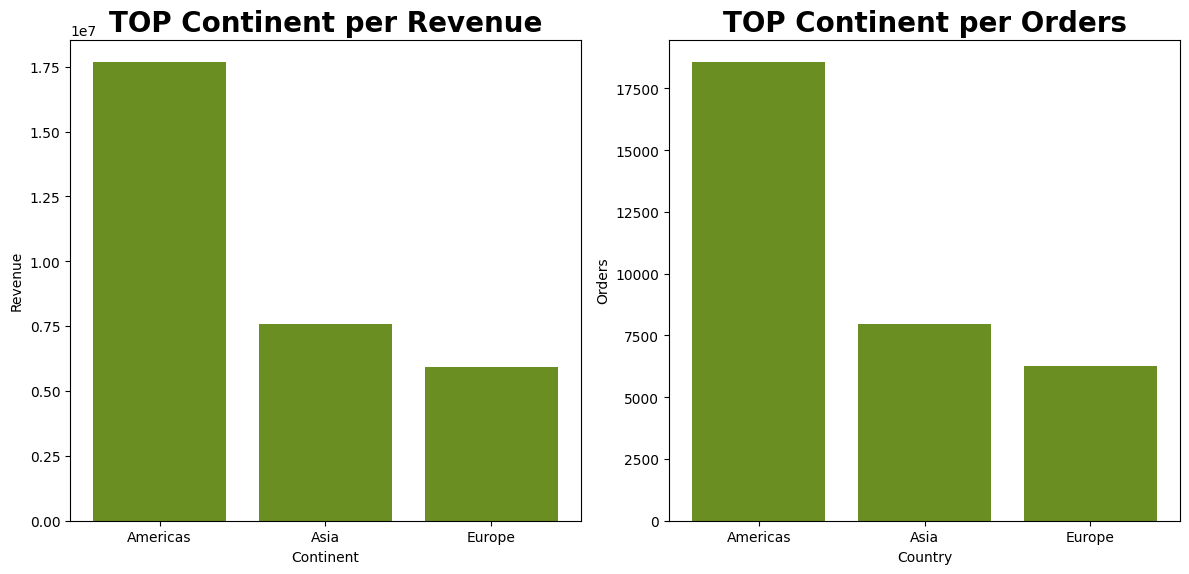

In [8]:
fig,ax=plt.subplots(1,2,figsize=(12,6))
ax[0].bar(top_by_continent["continent"], top_by_continent["price"],color="olivedrab")
ax[0].set_title("TOP Continent per Revenue",fontsize=20, fontweight="bold")
ax[0].set_xlabel("Continent")
ax[0].set_ylabel("Revenue")
ax[1].bar(orders_by_continent["continent"], orders_by_continent["name"],color="olivedrab")
ax[1].set_title("TOP Continent per Orders",fontsize=20, fontweight="bold")
ax[1].set_xlabel("Country")
ax[1].set_ylabel("Orders")
plt.tight_layout()

In [9]:
top_by_country = (
    df.groupby("country")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
    .head(5)
)
print(top_by_country)

          country       price
0   United States  13943553.9
1           India   2809762.0
2          Canada   2437921.0
3  United Kingdom    938317.9
4          France    710692.8


In [10]:
orders_by_country = (
    df.groupby("country")["name"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
    .head(5)
)

print(orders_by_country)

          country   name
0   United States  14673
1           India   3029
2          Canada   2560
3  United Kingdom   1029
4          France    678


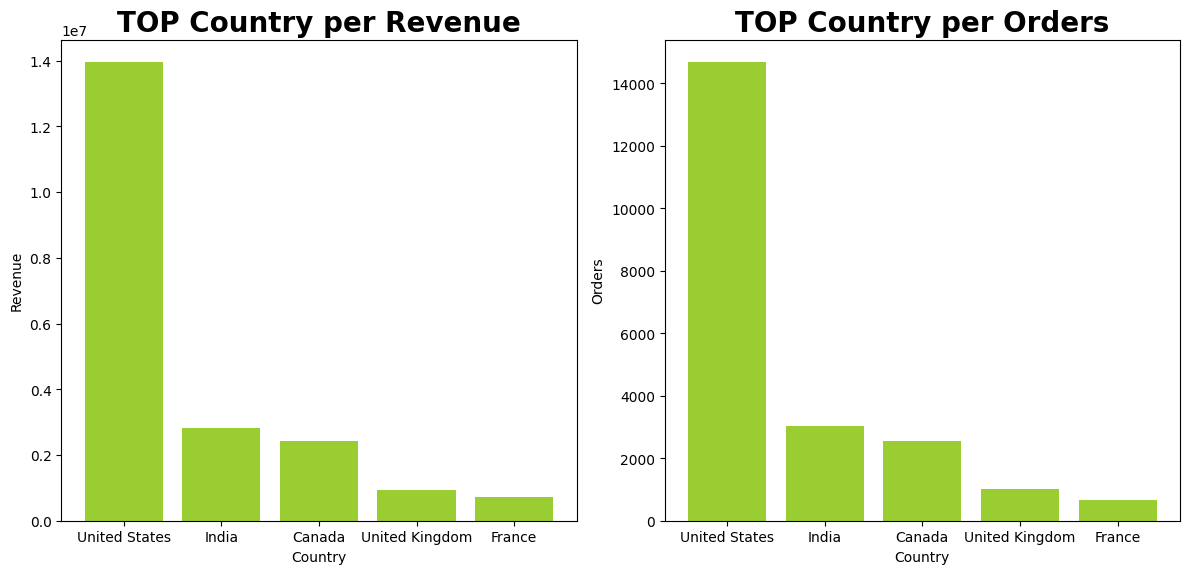

In [11]:
fig,ax=plt.subplots(1,2,figsize=(12,6))
ax[0].bar(top_by_country["country"], top_by_country["price"],color="yellowgreen")
ax[0].set_title("TOP Country per Revenue",fontsize=20, fontweight="bold")
ax[0].set_xlabel("Country")
ax[0].set_ylabel("Revenue")
ax[1].bar(orders_by_country["country"], orders_by_country["name"],color="yellowgreen")
ax[1].set_title("TOP Country per Orders",fontsize=20, fontweight="bold")
ax[1].set_xlabel("Country")
ax[1].set_ylabel("Orders")
plt.tight_layout()

In [12]:
orders_by_category = (
    df.groupby("category")["price"]
    .sum()
    .reset_index()
    .sort_values(by="price",ascending=False)
    .head(10)
)

print(orders_by_category)

                            category      price
12                 Sofas & armchairs  8388254.5
5                             Chairs  6147748.8
1                               Beds  4919725.0
2         Bookcases & shelving units  3640818.1
3               Cabinets & cupboards  2336499.5
9                  Outdoor furniture  2142222.2
13                    Tables & desks  1790307.5
6   Chests of drawers & drawer units   906562.5
0                      Bar furniture   735503.0
7               Children's furniture   467697.0


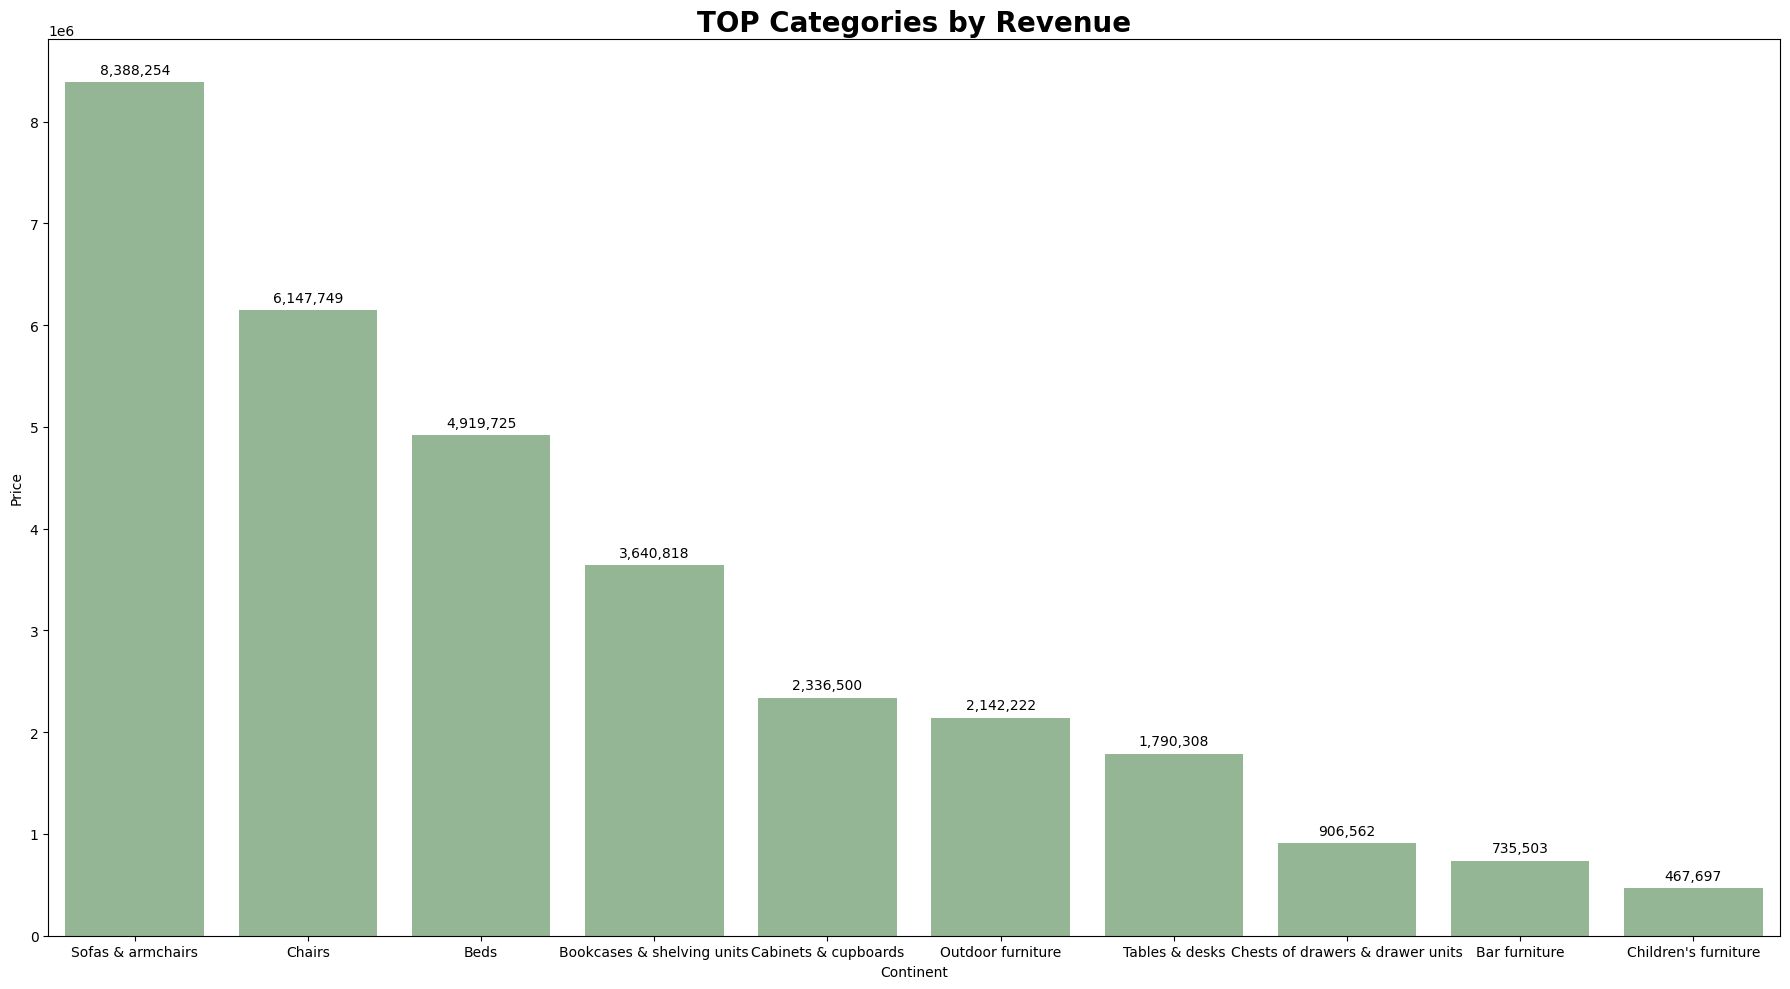

In [13]:
plt.figure(figsize=(18, 10))
plot=sns.barplot(data=orders_by_category,x="category",y="price",color="darkseagreen")
plt.title("TOP Categories by Revenue",fontsize=20, fontweight="bold")
plt.xlabel("Continent")
plt.ylabel("Price")
for p in plot.patches:
    plot.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
usa_df = df[df["country"] == "United States"]
usa_orders_by_category=(
       usa_df.groupby("category")["price"]
    .sum()
    .reset_index()
    .sort_values(by="price",ascending=False)
    .head(10)
)

print(usa_orders_by_category)

                            category      price
12                 Sofas & armchairs  3707144.5
5                             Chairs  2619773.8
1                               Beds  2213058.0
2         Bookcases & shelving units  1567606.9
3               Cabinets & cupboards   994545.5
9                  Outdoor furniture   929245.2
13                    Tables & desks   777865.0
6   Chests of drawers & drawer units   382388.0
0                      Bar furniture   330805.0
7               Children's furniture   207575.0


Compared to the overall results, the results for the United States are no different, with the same categories appearing in both data frames.

In [15]:
by_device = (
    df.groupby("device")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
total = df["price"].sum()
by_device["percentage"] =(by_device["price"] / total * 100)

print(by_device)

    device       price  percentage
0  desktop  18864039.0   59.002245
1   mobile  12384225.8   38.734924
2   tablet    723466.3    2.262831


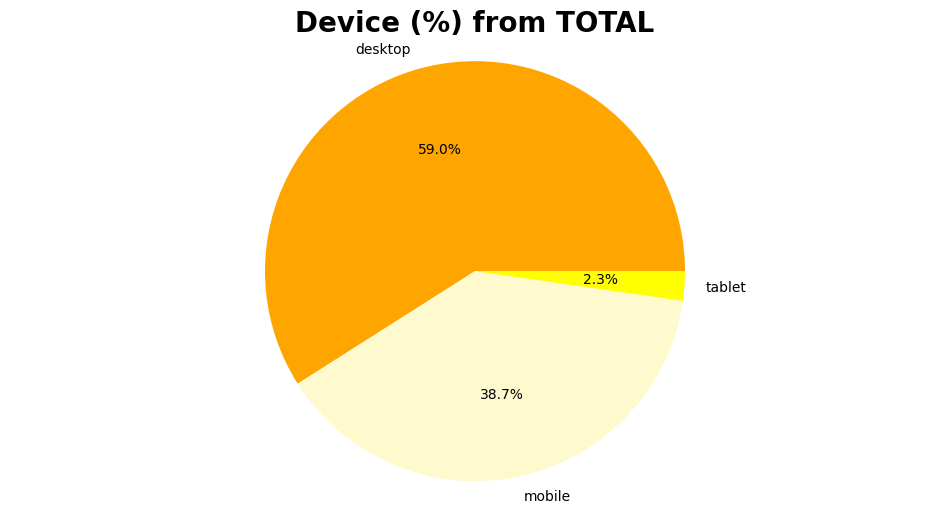

In [16]:
plt.figure(figsize=(12, 6))
plt.pie(by_device["price"], labels=by_device["device"], autopct='%1.1f%%',colors=["orange","lemonchiffon","yellow"])
plt.title("Device (%) from TOTAL",fontsize=20, fontweight="bold")
plt.axis("equal")
plt.show()

In [17]:
by_channel = (
    df.groupby("channel")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
total = df["price"].sum()
by_channel["percentage"] =(by_channel["price"] / total * 100)

print(by_channel)

          channel       price  percentage
0  Organic Search  11433151.6   35.760189
1     Paid Search   8511049.4   26.620546
2          Direct   7494923.4   23.442345
3   Social Search   2532105.7    7.919827
4       Undefined   2000501.0    6.257093


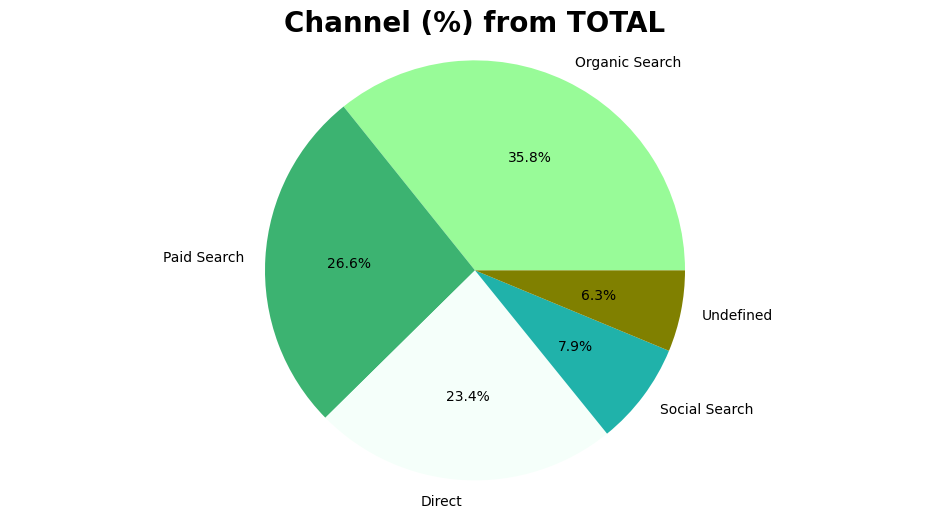

In [18]:
plt.figure(figsize=(12, 6))
plt.pie(by_channel["price"], labels=by_channel["channel"], autopct='%1.1f%%',colors=["palegreen","mediumseagreen","mintcream","lightseagreen","olive"])
plt.title("Channel (%) from TOTAL",fontsize=20, fontweight="bold")
plt.axis("equal")
plt.show()

In [19]:
verified = (
    df.groupby("is_verified")["account_id"]
    .count()
    .reset_index()
    .sort_values(by="account_id",ascending=False)

)
total = df["account_id"].count()
verified["percentage"] =(verified["account_id"] / total * 100)
print(total)
print(verified)


27945
   is_verified  account_id  percentage
1            1       20036   71.697978
0            0        7909   28.302022


You can see that the percentage of users who confirmed their email is higher than those who did not confirm it. In percentage terms, it is approximately 72%.

In [20]:
unsubscrible = (
    df.groupby("is_unsubscribed")["account_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()

)
total = df["account_id"].count()
unsubscrible["percentage"] =(unsubscrible["account_id"] / total * 100)
print(total)
print(unsubscrible)

27945
   is_unsubscribed  account_id  percentage
0                0       23210   83.056003
1                1        4735   16.943997


The percentage of users who unsubscribed from the newsletter is 16%.

In [21]:
unsubscribles = (
    df.groupby("is_unsubscribed")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)
print(unsubscribles)

   is_unsubscribed      price
0                0  2150796.9
1                1   431721.6


User behavior, in terms of sales, varies significantly depending on whether the user is subscribed to the newsletter. Statistics show that users who are subscribed to the newsletter bring $1,719,076 more profit to the company than those users who are unsubscribed.

In [22]:
contry_account_count = (
    df.groupby("country")["account_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()

)
top10=contry_account_count.head(10)
print(top10)


          country  account_id
0   United States       12384
1           India        2687
2          Canada        2067
3  United Kingdom         859
4          France         553
5           Spain         536
6          Taiwan         500
7           China         490
8         Germany         490
9           Italy         386


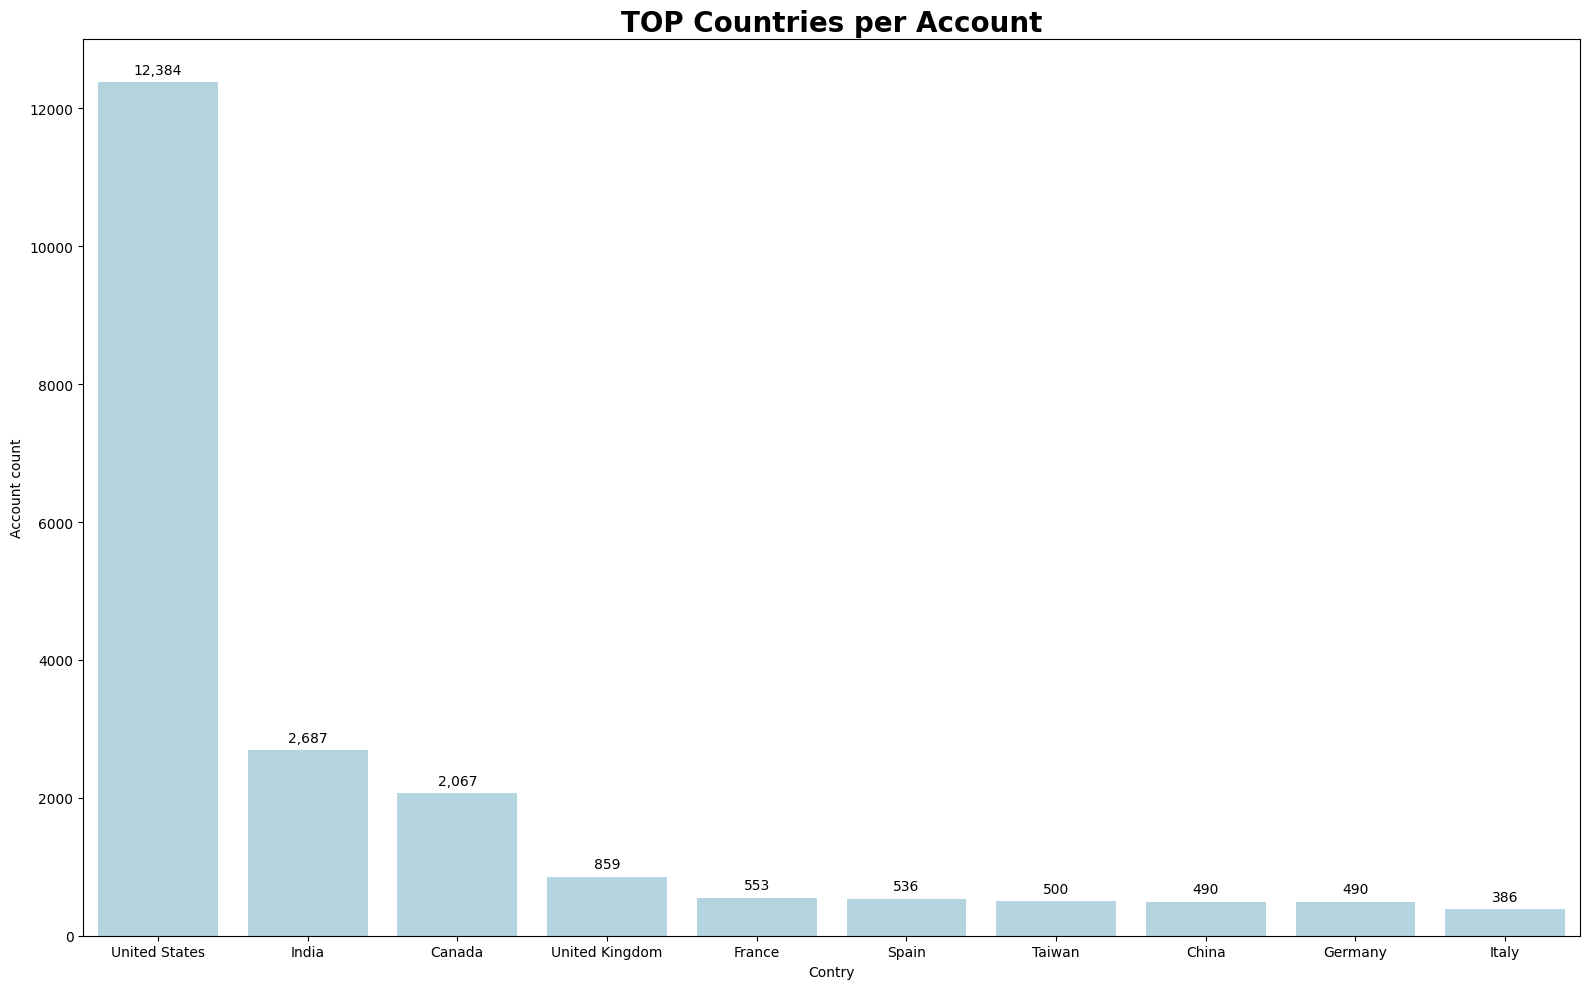

In [23]:
plt.figure(figsize=(16, 10))
country_count=sns.barplot(data=top10,x="country",y="account_id",color="lightblue")
plt.title("TOP Countries per Account",fontsize=20, fontweight="bold")
plt.xlabel("Contry")
plt.ylabel("Account count")
for a in country_count.patches:
    country_count.annotate(f'{a.get_height():,.0f}',
                (a.get_x() + a.get_width() / 2., a.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)
plt.tight_layout()
plt.show()

In [24]:
by_browser = (
    df.groupby("browser")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
total = df["price"].sum()
by_browser["percentage"] =(by_browser["price"] / total * 100)

print(by_browser)

           browser       price  percentage
0           Chrome  21826850.0   68.269215
1           Safari   7526544.0   23.541246
2          <Other>    923354.8    2.888035
3             Edge    716444.3    2.240868
4          Firefox    567523.6    1.775079
5  Android Webview    411014.4    1.285556


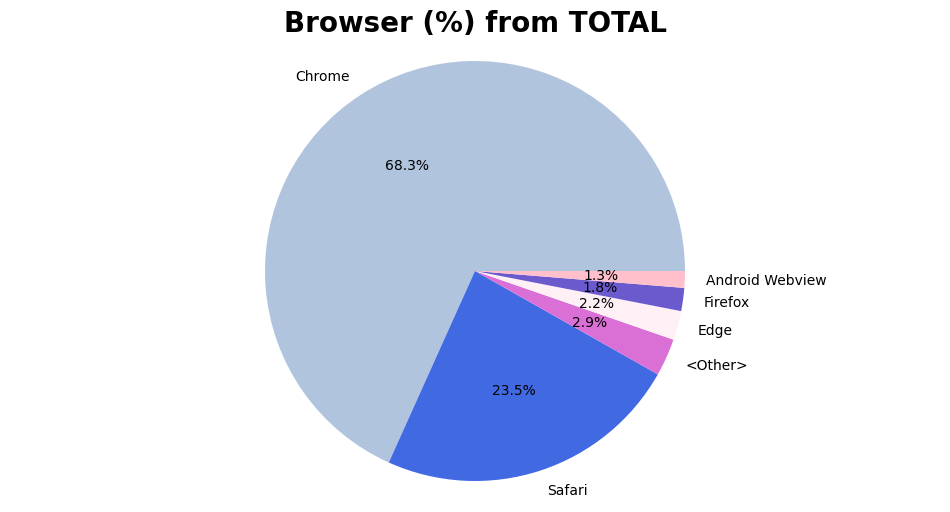

In [25]:
plt.figure(figsize=(12, 6))
plt.pie(by_browser["price"], labels=by_browser["browser"], autopct='%1.1f%%',colors=["lightsteelblue","royalblue","orchid","lavenderblush","slateblue","pink"])
plt.title("Browser (%) from TOTAL",fontsize=20, fontweight="bold")
plt.axis("equal")
plt.show()

In [26]:
popular_language = (
    df.groupby("language")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)
print(popular_language)

  language       price
0    en-us  14715870.2
1    en-gb   2181314.3
2       zh   1053040.6
3       en    995536.9
4    en-ca    778852.6
5       fr    579024.5
6    es-es    514573.1
7       ko    298528.8
8       de    257088.7


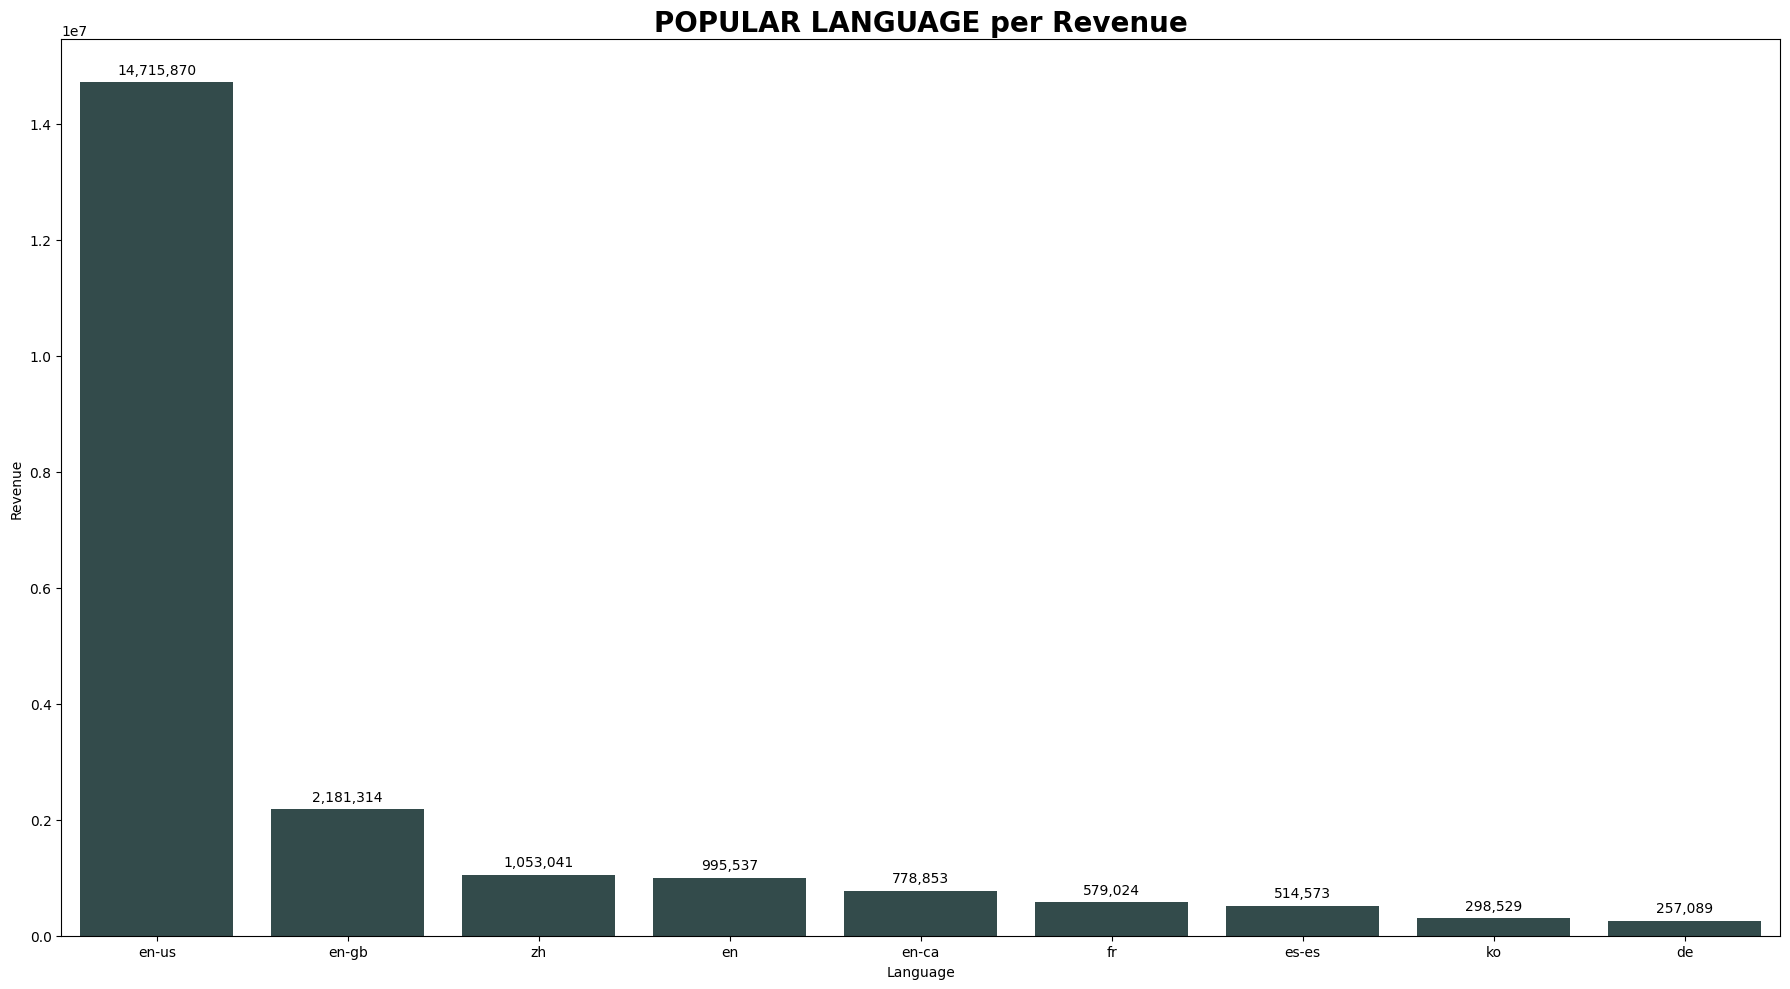

In [27]:
plt.figure(figsize=(18, 10))
plot=sns.barplot(data=popular_language,x="language",y="price",color="darkslategray")
plt.title("POPULAR LANGUAGE per Revenue",fontsize=20, fontweight="bold")
plt.xlabel("Language")
plt.ylabel("Revenue")
for p in plot.patches:
    plot.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)
plt.tight_layout()
plt.show()

In [28]:
operating_systems = (
    df.groupby("operating_system")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)
print(operating_systems)

  operating_system       price
0              Web  18445904.5
1          Windows   3804989.0
2              iOS   3603329.4
3          Android   2789985.1
4        Macintosh   2504967.3
5          <Other>    822555.8


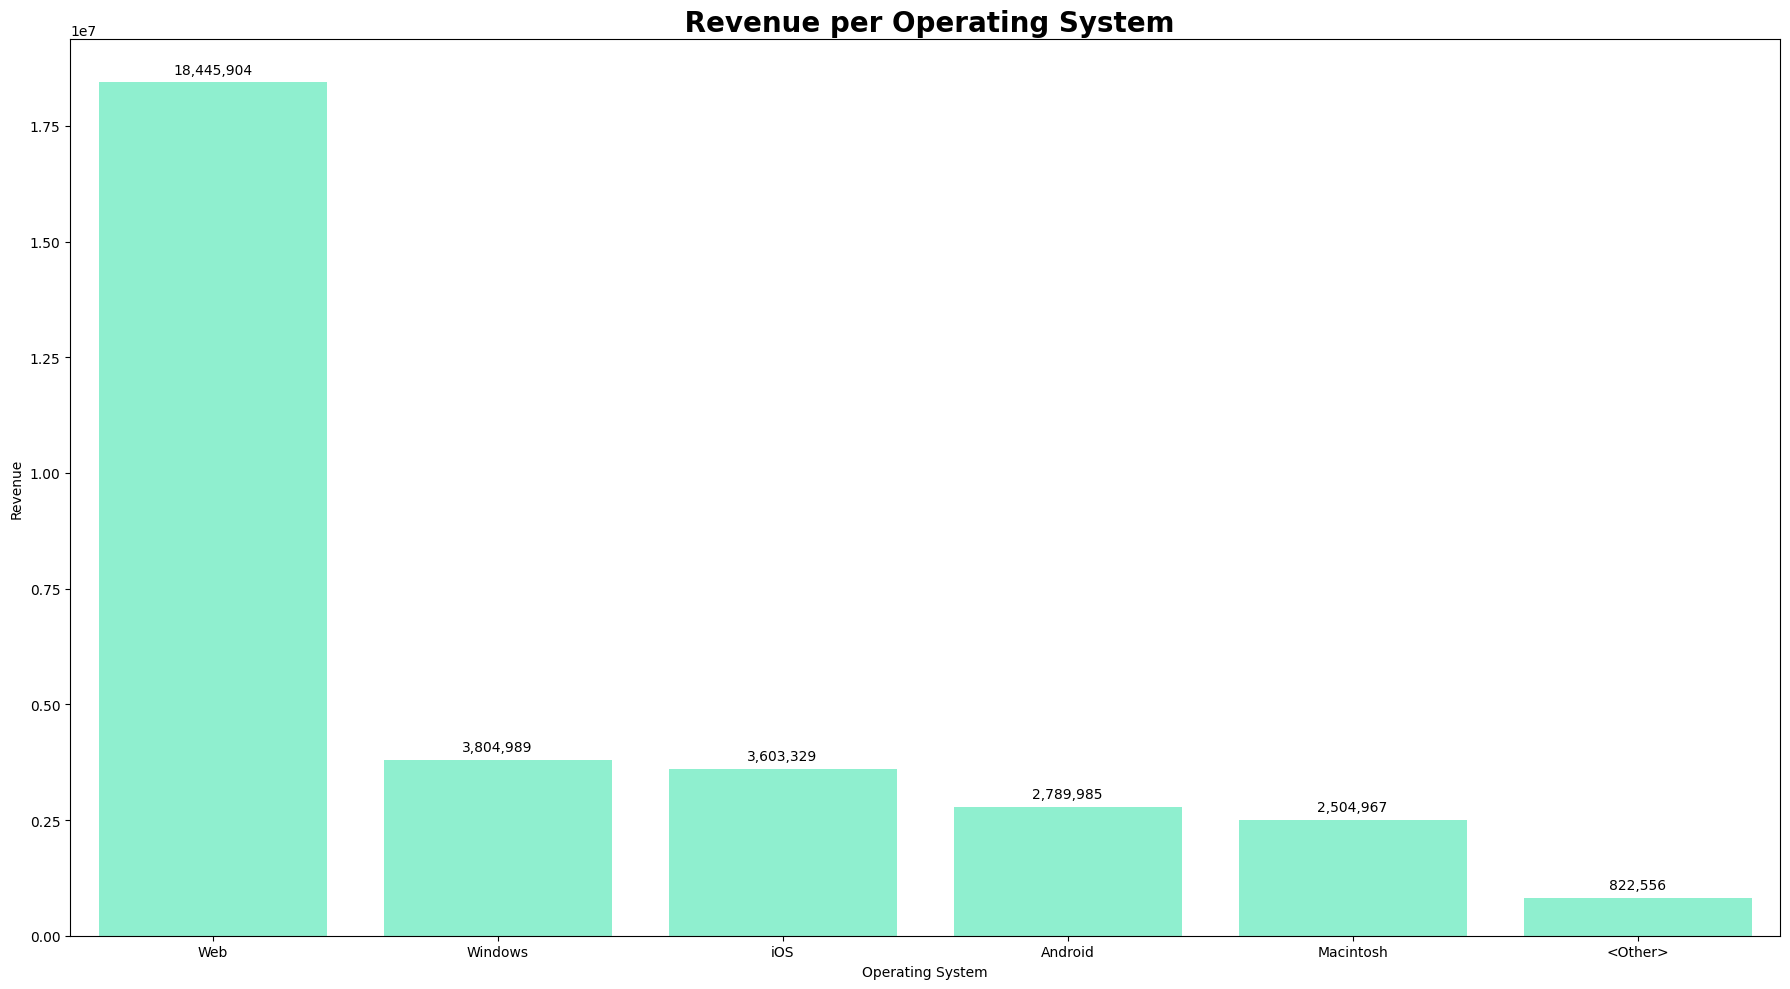

In [29]:
plt.figure(figsize=(18, 10))
plot=sns.barplot(data=operating_systems,x="operating_system",y="price",color="aquamarine")
plt.title(" Revenue per Operating System",fontsize=20, fontweight="bold")
plt.xlabel("Operating System")
plt.ylabel("Revenue")
for p in plot.patches:
    plot.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)
plt.tight_layout()
plt.show()

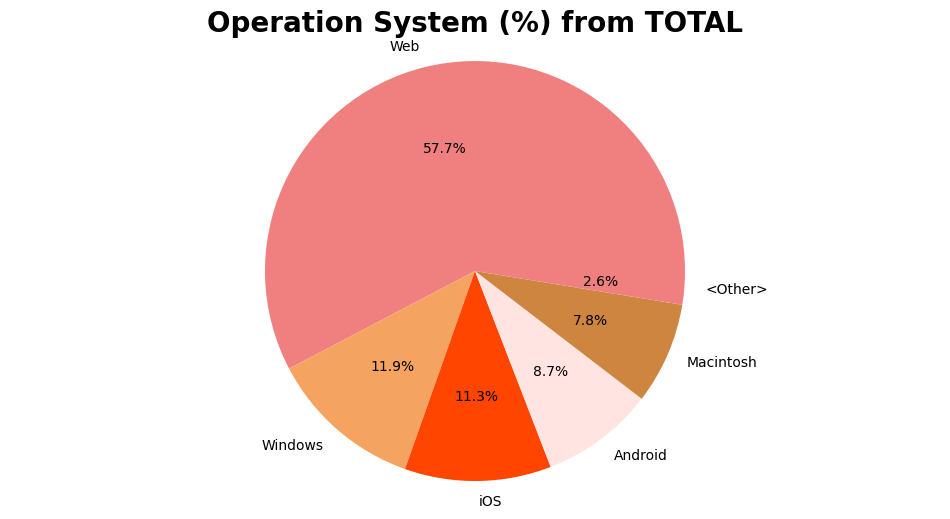

In [30]:
total = df["price"].sum()
operating_systems["percentage"] =(operating_systems["price"] / total * 100)

plt.figure(figsize=(12, 6))
plt.pie(operating_systems["price"], labels=operating_systems["operating_system"], autopct='%1.1f%%',colors=["lightcoral","sandybrown","orangered","mistyrose","peru"])
plt.title("Operation System (%) from TOTAL",fontsize=20, fontweight="bold")
plt.axis("equal")
plt.show()

In [31]:
dynamics= (
    df.groupby("date")["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)
print(dynamics)

          date     price
0   2020-12-08  680509.5
1   2020-12-10  624104.6
2   2021-01-06  609763.8
3   2020-12-16  553134.9
4   2020-12-09  551811.6
..         ...       ...
87  2020-11-07  200892.2
88  2021-01-28       0.0
89  2021-01-29       0.0
90  2021-01-30       0.0
91  2021-01-31       0.0

[92 rows x 2 columns]


/tmp/ipykernel_8343/303745385.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_season = df.groupby("Season")["price"].sum().sort_values()
/tmp/ipykernel_8343/303745385.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0.0001)` for the same effect.

  sns.lineplot(data = df, x = "Season", y = "price", marker = "o",color="red",ci=0.0001)


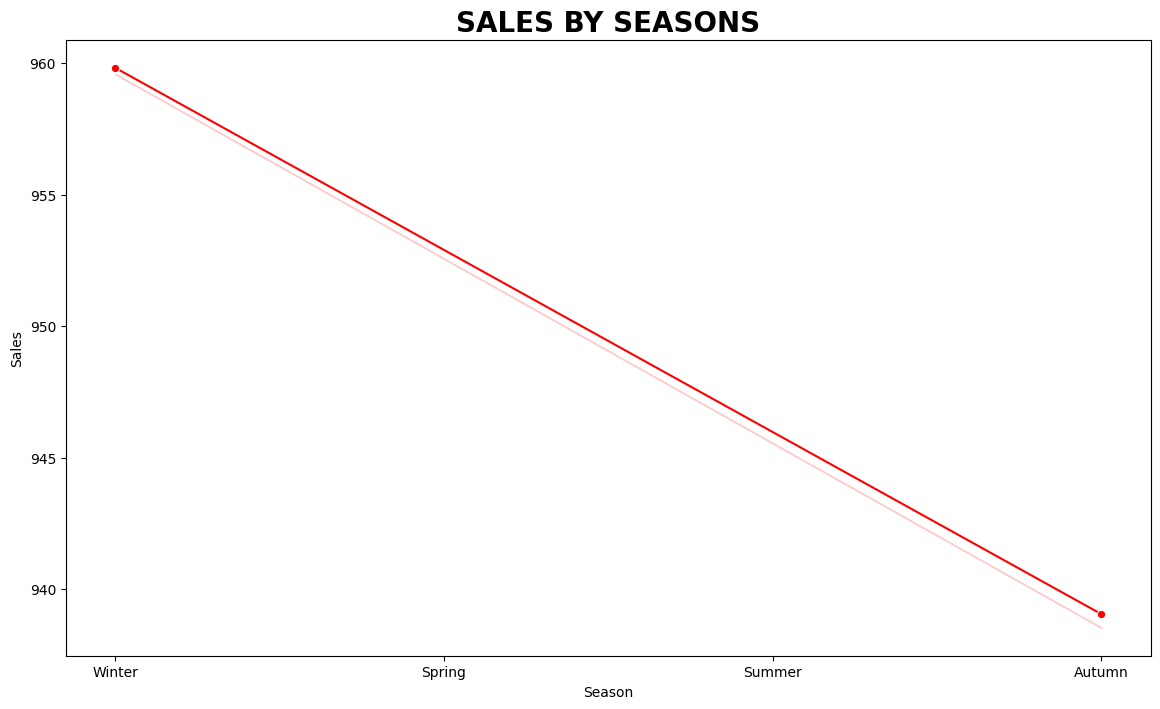

In [32]:
df["date"] = pd.to_datetime(df["date"])
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}
df["Season"] = df["date"].dt.month.map(season_map)
season_order = ["Winter", "Spring", "Summer", "Autumn"]
df["Season"] = pd.Categorical(df["Season"], categories=season_order, ordered=True)
sales_by_season = df.groupby("Season")["price"].sum().sort_values()
plt.figure(figsize=(14,8))
sns.lineplot(data = df, x = "Season", y = "price", marker = "o",color="red",ci=0.0001)
plt.title("SALES BY SEASONS",fontsize=20, fontweight="bold", color="black", ha="center")
plt.xlabel("Season")
plt.ylabel("Sales")
plt.show()

In [33]:
Continent_dynamic= (
    df.groupby(["continent","date"])["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)
print(Continent_dynamic)

     continent       date     price
0     Americas 2021-01-06  374614.9
1     Americas 2020-12-10  363825.4
2     Americas 2020-12-08  342328.6
3     Americas 2020-12-09  320100.1
4     Americas 2020-12-16  308376.0
..         ...        ...       ...
547  (not set) 2020-11-01       0.0
548    Oceania 2021-01-28       0.0
549    Oceania 2021-01-29       0.0
550    Oceania 2021-01-30       0.0
551    Oceania 2021-01-31       0.0

[552 rows x 3 columns]


/tmp/ipykernel_8343/2958432530.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0.1)` for the same effect.

  sns.lineplot(data=df_filters, x = "date", y = "price", hue = "continent", marker = "o",ci=0.1)


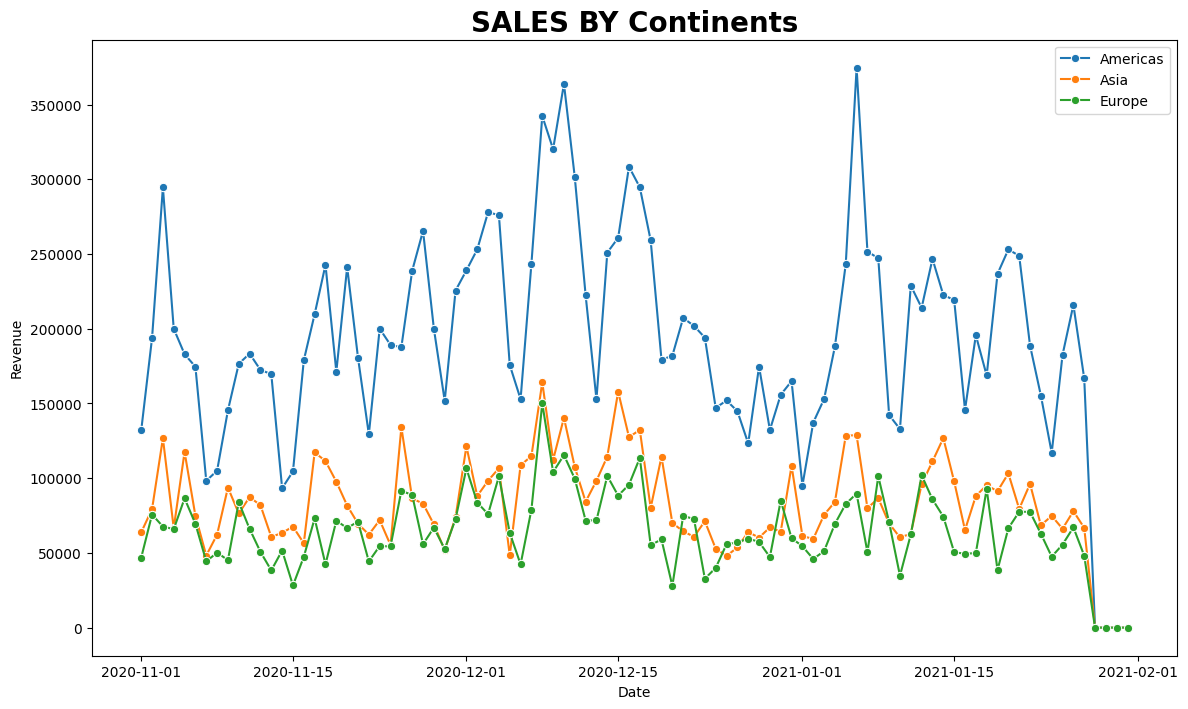

In [34]:
selected_continents = ["Americas", "Asia", "Europe"]
df_filters = Continent_dynamic[Continent_dynamic["continent"].isin(selected_continents)].copy()
plt.figure(figsize=(14,8))
sns.lineplot(data=df_filters, x = "date", y = "price", hue = "continent", marker = "o",ci=0.1)
plt.legend(loc = "upper right")
plt.title("SALES BY Continents",fontsize=20, fontweight="bold", color="black", ha="center")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [35]:
Channel_dynamic= (
    df.groupby(["channel","date"])["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)
print(Channel_dynamic)

            channel       date     price
0    Organic Search 2020-12-08  270436.6
1    Organic Search 2021-01-06  238704.5
2    Organic Search 2020-12-10  237895.9
3    Organic Search 2020-12-09  212437.2
4       Paid Search 2020-12-08  203608.1
..              ...        ...       ...
455   Social Search 2021-01-31       0.0
456       Undefined 2021-01-28       0.0
457       Undefined 2021-01-29       0.0
458       Undefined 2021-01-30       0.0
459       Undefined 2021-01-31       0.0

[460 rows x 3 columns]


/tmp/ipykernel_8343/1989420684.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0.1)` for the same effect.

  sns.lineplot(data=Channel_dynamic, x = "date", y = "price", hue = "channel", marker = "o",ci=0.1)


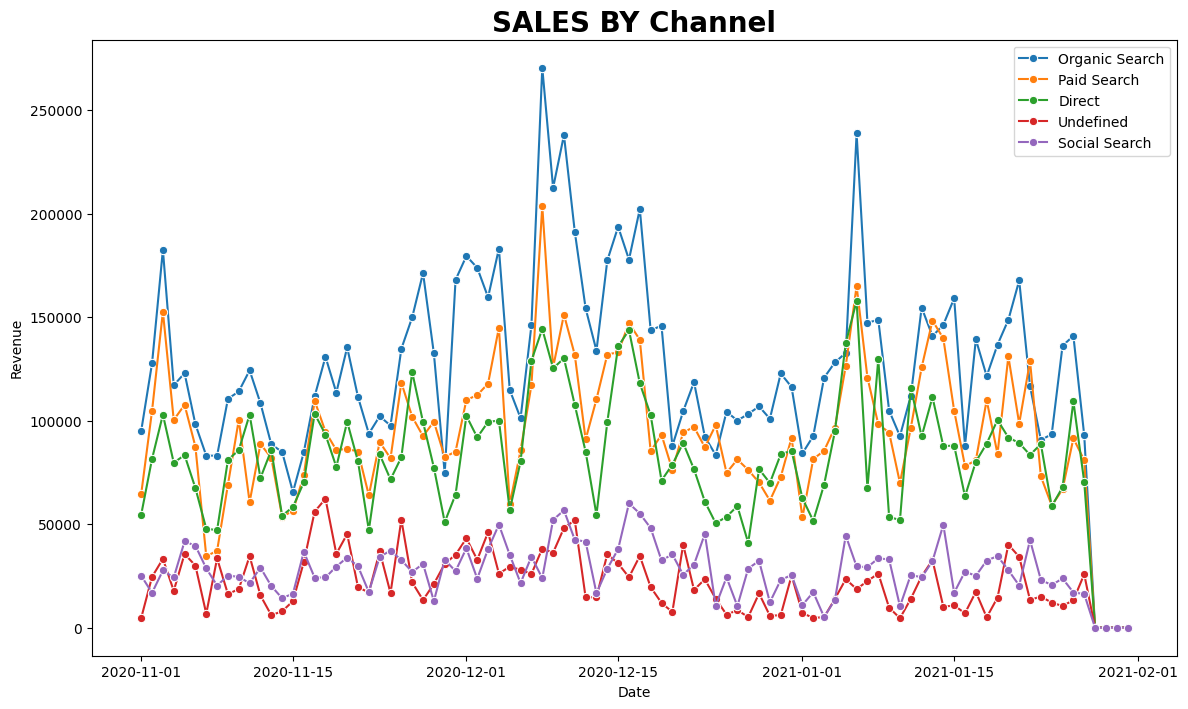

In [36]:
plt.figure(figsize=(14,8))
sns.lineplot(data=Channel_dynamic, x = "date", y = "price", hue = "channel", marker = "o",ci=0.1)
plt.legend(loc = "upper right")
plt.title("SALES BY Channel",fontsize=20, fontweight="bold", color="black", ha="center")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

In [37]:
Device_dynamic= (
    df.groupby(["device","date"])["price"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()

)
print(Device_dynamic)

      device       date     price
0    desktop 2020-12-08  394823.7
1    desktop 2020-12-10  382502.3
2    desktop 2021-01-06  363587.9
3    desktop 2020-12-17  353620.9
4    desktop 2020-12-11  332623.6
..       ...        ...       ...
271   mobile 2021-01-28       0.0
272   tablet 2021-01-28       0.0
273   tablet 2021-01-29       0.0
274   tablet 2021-01-30       0.0
275   tablet 2021-01-31       0.0

[276 rows x 3 columns]


/tmp/ipykernel_8343/2462952306.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 0.1)` for the same effect.

  sns.lineplot(data=Device_dynamic, x = "date", y = "price", hue = "device", marker = "o",ci=0.1)


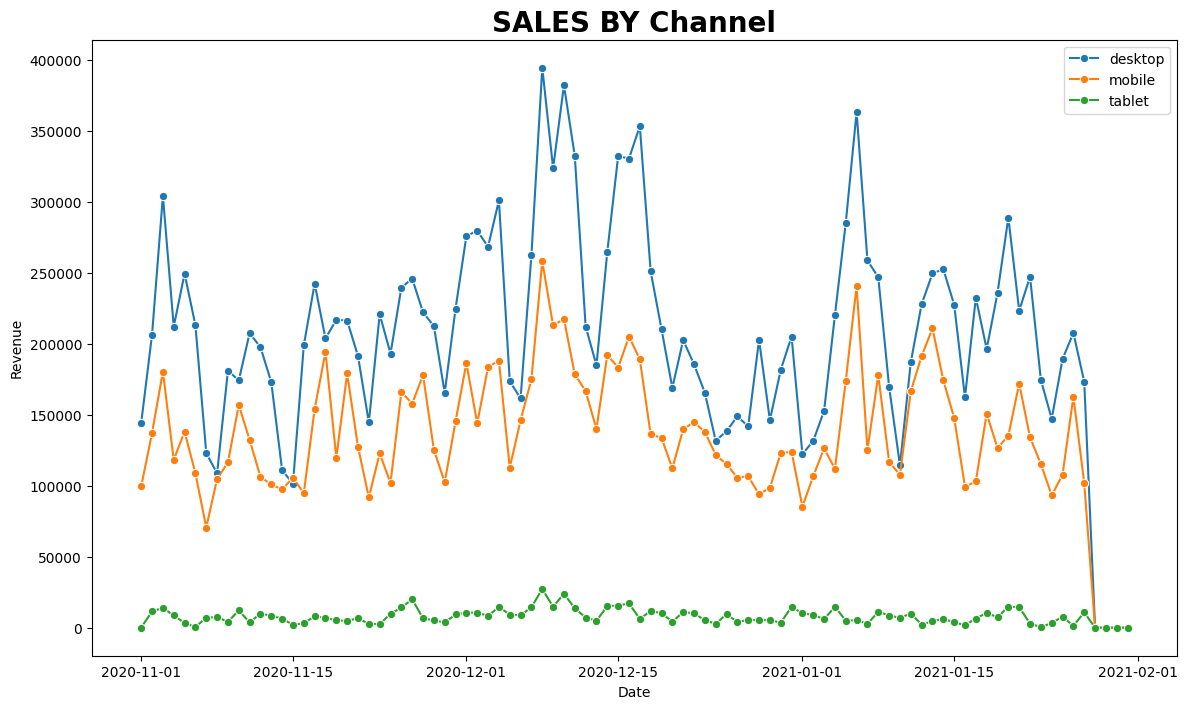

In [38]:
plt.figure(figsize=(14,8))
sns.lineplot(data=Device_dynamic, x = "date", y = "price", hue = "device", marker = "o",ci=0.1)
plt.legend(loc = "upper right")
plt.title("SALES BY Channel",fontsize=20, fontweight="bold", color="black", ha="center")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

# Conclusions on dynamics:
After analyzing the linear graphs that reflect trends and dynamics, we see a certain seasonality in winter. A significant surge (peak) is visible, I assume that this is a Christmas sale and another peak in early January. Also, it is clear that America is the clear leader in revenue. Asia and Europe are approximately at the same level, but Asia is several times ahead of Europe. We see some tendency to a sharp decline in indicators at the end of all visualizations. Also, the best are desktop devices and the difference between it and the tablet is significant. Therefore, the income from tablets is minimal and stable.

In [39]:
pivot_channel=df.pivot_table(index="channel",values="ga_session_id",aggfunc="count").sort_values(by="ga_session_id",ascending=False)
print(pivot_channel)

                ga_session_id
channel                      
Organic Search         124425
Paid Search             94341
Direct                  81382
Social Search           27914
Undefined               21483


In [40]:
pivot_device=df.pivot_table(index="device",values="ga_session_id",aggfunc="count").sort_values(by="ga_session_id",ascending=False)
print(pivot_device)

         ga_session_id
device                
desktop         204429
mobile          137267
tablet            7849


In [41]:
pivot_channel_device=df.pivot_table(index=["channel","device"],values="ga_session_id",aggfunc="count").sort_values(by="ga_session_id",ascending=False)
print(pivot_channel_device)

                        ga_session_id
channel        device                
Organic Search desktop          72622
Paid Search    desktop          55167
Organic Search mobile           49014
Direct         desktop          47825
Paid Search    mobile           37034
Direct         mobile           31745
Social Search  desktop          16288
Undefined      desktop          12527
Social Search  mobile           10988
Undefined      mobile            8486
Organic Search tablet            2789
Paid Search    tablet            2140
Direct         tablet            1812
Social Search  tablet             638
Undefined      tablet             470


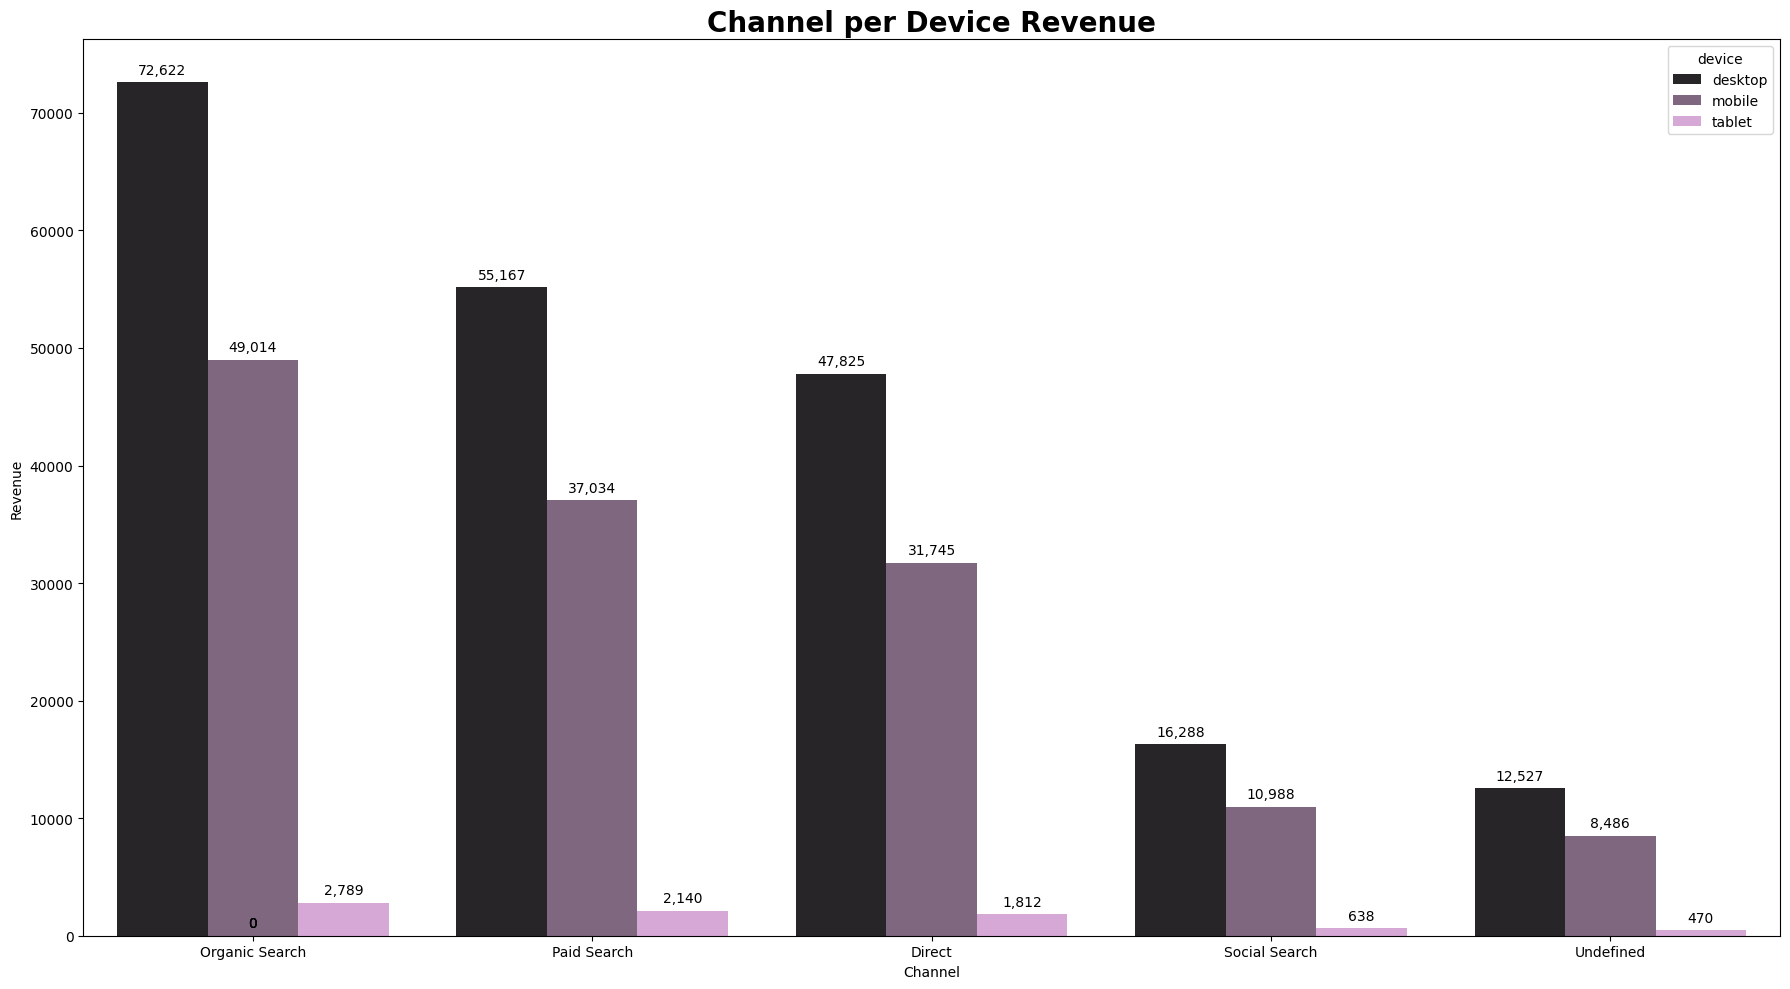

In [42]:
from matplotlib import colors
plt.figure(figsize=(18, 10))
plot=sns.barplot(data=pivot_channel_device,x="channel",y="ga_session_id",hue="device",palette="dark:plum")
plt.title("Channel per Device Revenue",fontsize=20, fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("Revenue")
for p in plot.patches:
    plot.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)
plt.tight_layout()
plt.show()

In [43]:
top_countries = (
    df.groupby("country")["price"]
    .sum()
    .nlargest(5)
    .index)
top_categories = (
    df.groupby("category")["price"]
    .sum()
    .nlargest(10)
    .index)

filtered_df = df[
    df["country"].isin(top_countries) &
    df["category"].isin(top_categories)
]

pivot_sales = filtered_df.pivot_table(
    values="price",
    index="category",
    columns="country",
    aggfunc="sum"
)

print("Pivot Table Top-10 Category and Top-5 Country: ")
print(pivot_sales)

Pivot Table Top-10 Category and Top-5 Country: 
country                             Canada    France     India  \
category                                                         
Bar furniture                      51724.0   11199.0   57657.0   
Beds                              354772.0  116414.0  358319.5   
Bookcases & shelving units        278981.9   73830.0  364507.4   
Cabinets & cupboards              181802.0   59101.5  191888.0   
Chairs                            417740.8  134029.4  544309.2   
Chests of drawers & drawer units   71952.0   21544.5   73111.0   
Children's furniture               30264.0   14258.0   39177.0   
Outdoor furniture                 185322.8   40486.4  162289.4   
Sofas & armchairs                 692427.5  187735.0  788430.0   
Tables & desks                    132678.0   42299.0  186157.5   

country                           United Kingdom  United States  
category                                                         
Bar furniture              

In [44]:
pivot_operating_system=df.pivot_table(index="operating_system",values="ga_session_id",aggfunc="count").sort_values(by="ga_session_id",ascending=False)
print(pivot_operating_system)

                  ga_session_id
operating_system               
Web                      203909
Windows                   40937
iOS                       40102
Android                   29808
Macintosh                 26116
<Other>                    8673


In [45]:
pivot_browser=df.pivot_table(index="browser",values="ga_session_id",aggfunc="count").sort_values(by="ga_session_id",ascending=False)
print(pivot_browser)

                 ga_session_id
browser                       
Chrome                  238460
Safari                   83254
<Other>                   8930
Edge                      8023
Firefox                   6433
Android Webview           4445


In [46]:
session_cnt=( df.groupby(["date"])["ga_session_id"]
    .count()
    .reset_index()
)
revenue_day=(df.groupby(["date"])["price"]
.sum()
.reset_index()
)
print(session_cnt)
print(revenue_day)

         date  ga_session_id
0  2020-11-01           2576
1  2020-11-02           3599
2  2020-11-03           5173
3  2020-11-04           4184
4  2020-11-05           3743
..        ...            ...
87 2021-01-27           4435
88 2021-01-28           4112
89 2021-01-29           3700
90 2021-01-30           2845
91 2021-01-31           2812

[92 rows x 2 columns]
         date     price
0  2020-11-01  244292.5
1  2020-11-02  355506.8
2  2020-11-03  498979.6
3  2020-11-04  339187.1
4  2020-11-05  391276.6
..        ...       ...
87 2021-01-27  286340.7
88 2021-01-28       0.0
89 2021-01-29       0.0
90 2021-01-30       0.0
91 2021-01-31       0.0

[92 rows x 2 columns]


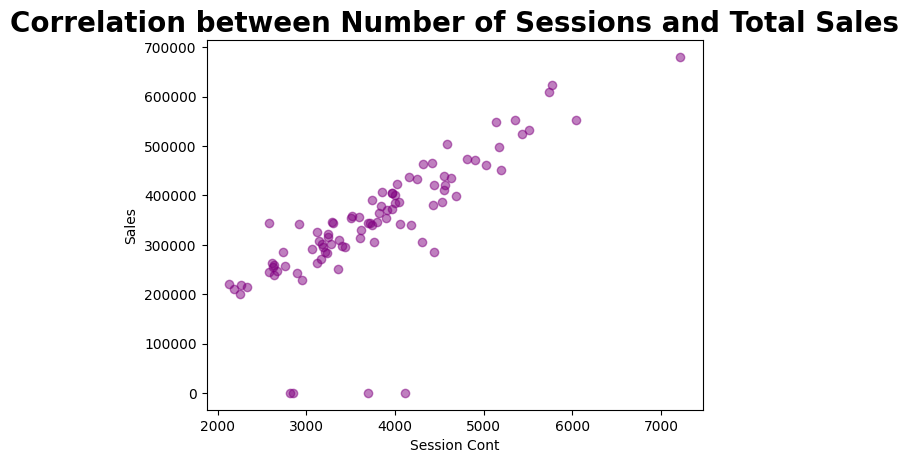

In [47]:
plt.scatter(session_cnt["ga_session_id"],revenue_day["price"],color="purple",alpha=0.5)
plt.title("Correlation between Number of Sessions and Total Sales",fontsize=20, fontweight="bold")
plt.xlabel("Session Cont")
plt.ylabel("Sales")
plt.show()

Judging by the graph, there is a clear strong positive linear correlation between the number of sessions and total sales. The points line up along the baseline: the more sessions, the higher the sales. You can also notice a few points that are far from the main trend, these may be outliers (abnormal values).

In [48]:
from scipy.stats import pearsonr
print(pearsonr(session_cnt["ga_session_id"],revenue_day["price"]))

PearsonRResult(statistic=np.float64(0.7910809164540891), pvalue=np.float64(6.483532312080735e-21))


There is a strong statistically significant correlation between the number of sessions and sales volume (r = 0.79, p < 0.001). Anomalies (sessions without sales) exist, but they do not disrupt the overall trend.

In [49]:
top_3_list = df.groupby("continent")["price"].sum().nlargest(3).index
pivot_top3 = (
    df[df["continent"].isin(top_3_list)]
    .groupby(["date", "continent"])["price"]
    .sum()
    .unstack()
)

print(pivot_top3)

continent   Americas      Asia   Europe
date                                   
2020-11-01  132002.5   63823.0  46908.0
2020-11-02  193861.0   79370.0  75710.8
2020-11-03  294529.8  126737.8  67692.0
2020-11-04  200009.5   66602.0  65915.0
2020-11-05  182988.2  117608.4  86540.0
...              ...       ...      ...
2021-01-27  166735.5   66783.1  48156.1
2021-01-28       0.0       0.0      0.0
2021-01-29       0.0       0.0      0.0
2021-01-30       0.0       0.0      0.0
2021-01-31       0.0       0.0      0.0

[92 rows x 3 columns]


In [50]:
print(pivot_top3.corr())

continent  Americas      Asia    Europe
continent                              
Americas   1.000000  0.792025  0.770586
Asia       0.792025  1.000000  0.768427
Europe     0.770586  0.768427  1.000000


The pair Americas and Asia with a coefficient of 0.792. This means that these markets are leaders and almost identical. Business does not depend on the local characteristics of a single continent. There is a very high level of correlation between the top 3 continents.

In [51]:
pairs = [("Americas", "Asia"), ("Americas", "Europe"), ("Asia", "Europe")]
for p1, p2 in pairs:
    data = pivot_top3[[p1, p2]].dropna()
    corr, p_val = pearsonr(data[p1], data[p2])

    print(f" Pair:{p1} - {p2}:")
    print(f"  p-value: {p_val:.4e}")

 Pair:Americas - Asia:
  p-value: 5.4092e-21
 Pair:Americas - Europe:
  p-value: 2.6714e-19
 Pair:Asia - Europe:
  p-value: 3.8649e-19


It can be seen that there is a strong positive correlation between sales volumes in key regions (Americas, Asia, Europe). The obtained p-values ​​< 0.05 allow us to completely reject the null hypothesis of no relationship (the hypothesis that nothing changes).

In [52]:
pivot_channels = df.pivot_table(
    index="date",
    columns="channel",
    values="price",
    aggfunc="sum"
).fillna(0)
print(pivot_channels)

channel       Direct  Organic Search  Paid Search  Social Search  Undefined
date                                                                       
2020-11-01   54669.5         95112.0      64688.0        25078.0     4745.0
2020-11-02   81561.5        127746.5     104780.8        16843.0    24575.0
2020-11-03  102909.5        182521.9     152641.3        27652.5    33254.4
2020-11-04   79683.6        117067.1     100332.0        24257.4    17847.0
2020-11-05   83367.6        122938.4     107648.0        41693.2    35629.4
...              ...             ...          ...            ...        ...
2021-01-27   70423.1         92921.1      80869.5        16282.0    25845.0
2021-01-28       0.0             0.0          0.0            0.0        0.0
2021-01-29       0.0             0.0          0.0            0.0        0.0
2021-01-30       0.0             0.0          0.0            0.0        0.0
2021-01-31       0.0             0.0          0.0            0.0        0.0

[92 rows x 

In [53]:
print(pivot_channels.corr())

channel           Direct  Organic Search  Paid Search  Social Search  \
channel                                                                
Direct          1.000000        0.837833     0.814072       0.604060   
Organic Search  0.837833        1.000000     0.870086       0.583117   
Paid Search     0.814072        0.870086     1.000000       0.596428   
Social Search   0.604060        0.583117     0.596428       1.000000   
Undefined       0.517505        0.526068     0.521961       0.455126   

channel         Undefined  
channel                    
Direct           0.517505  
Organic Search   0.526068  
Paid Search      0.521961  
Social Search    0.455126  
Undefined        1.000000  


In [54]:
import itertools
channels = pivot_channels.columns
for ch1, ch2 in itertools.combinations(channels, 2):
    corr, p_val = pearsonr(pivot_channels[ch1], pivot_channels[ch2])
    print(f"{ch1} vs {ch2}:")
    print(f"  p-value: {p_val:.4e}")

Direct vs Organic Search:
  p-value: 2.1904e-25
Direct vs Paid Search:
  p-value: 5.8964e-23
Direct vs Social Search:
  p-value: 1.8319e-10
Direct vs Undefined:
  p-value: 1.2754e-07
Organic Search vs Paid Search:
  p-value: 2.1420e-29
Organic Search vs Social Search:
  p-value: 1.0662e-09
Organic Search vs Undefined:
  p-value: 7.2282e-08
Paid Search vs Social Search:
  p-value: 3.5323e-10
Paid Search vs Undefined:
  p-value: 9.5096e-08
Social Search vs Undefined:
  p-value: 5.1619e-06


The relationship between Direct, Organic, and Paid Search channels is statistically significant and very strong.

In [55]:
top_5_categories = df.groupby("category")["price"].sum().nlargest(5).index
pivot_categories = (
    df[df["category"].isin(top_5_categories)]
    .pivot_table(index="date", columns="category", values="price", aggfunc="sum")
    .fillna(0)
)
print(pivot_categories)

category       Beds  Bookcases & shelving units  Cabinets & cupboards  \
date                                                                    
2020-11-01  14041.0                     36701.0               13591.5   
2020-11-02  79683.5                     40979.0               21623.0   
2020-11-03  66219.5                     64360.1               33555.5   
2020-11-04  48939.0                     35719.8               19266.0   
2020-11-05  23449.0                     40998.8               29235.0   
...             ...                         ...                   ...   
2021-01-23  37116.0                     29862.7               26068.0   
2021-01-24  23294.0                     25396.0               23664.5   
2021-01-25  47303.5                     25919.6               33028.0   
2021-01-26  69894.5                     39119.2               20218.0   
2021-01-27  43080.0                     33874.2               29739.0   

category     Chairs  Sofas & armchairs  
date     

In [56]:
for cat1, cat2 in itertools.combinations(pivot_categories.columns, 2):
    corr, p_val = pearsonr(pivot_categories[cat1], pivot_categories[cat2])
    print(f"{cat1[:22]} vs {cat2[:22]}, {corr}, {p_val}")

Beds vs Bookcases & shelving u, 0.5929126076179512, 1.1549982399950595e-09
Beds vs Cabinets & cupboards, 0.5146092811149645, 2.9109296191322004e-07
Beds vs Chairs, 0.5544997375988838, 2.079182865492252e-08
Beds vs Sofas & armchairs, 0.5353782861422639, 7.687332925177328e-08
Bookcases & shelving u vs Cabinets & cupboards, 0.5394281705433275, 5.8672250979394714e-08
Bookcases & shelving u vs Chairs, 0.6370904868409913, 2.5045503773672356e-11
Bookcases & shelving u vs Sofas & armchairs, 0.6661941326624645, 1.4069719486806666e-12
Cabinets & cupboards vs Chairs, 0.5728699991065372, 5.46590349515409e-09
Cabinets & cupboards vs Sofas & armchairs, 0.6575633672296022, 3.4150555904339523e-12
Chairs vs Sofas & armchairs, 0.5782483467930374, 3.6388330532540413e-09


Here the results are unambiguous. The p-values ​​are e-07, e-09 or even e-12. All of them are significantly less than 0.05, the relationships between all pairs of categories are statistically significant. This is not a coincidence. There is a possibility that the results are caused by a pattern. In general, the correlation is of medium level.

In [57]:
df["is_registered"] = df["account_id"].notnull()
daily_sales = df.groupby(["date","is_registered"])["price"].sum().reset_index()
pivot_sales = daily_sales.pivot(index="date", columns="is_registered", values="price")
pivot_sales.columns = ["non-registered","registered"]
print(pivot_sales)

            non-registered  registered
date                                  
2020-11-01        222745.5     21547.0
2020-11-02        310550.0     44956.8
2020-11-03        469829.1     29150.5
2020-11-04        318204.9     20982.2
2020-11-05        365942.0     25334.6
...                    ...         ...
2021-01-27        271727.1     14613.6
2021-01-28             0.0         NaN
2021-01-29             0.0         NaN
2021-01-30             0.0         NaN
2021-01-31             0.0         NaN

[92 rows x 2 columns]


In [58]:
registered_sales = df[df["is_registered"] == True]["price"]
unregistered_sales = df[df["is_registered"] == False]["price"]
print(f"Registered Users:{len(registered_sales)}, Середнє={registered_sales.mean()}")
print(f"Unregistered Users:{len(unregistered_sales)}, Середнє={unregistered_sales.mean()}")

Registered Users:27945, Середнє=928.6294498381875
Unregistered Users:321600, Середнє=955.529232369867


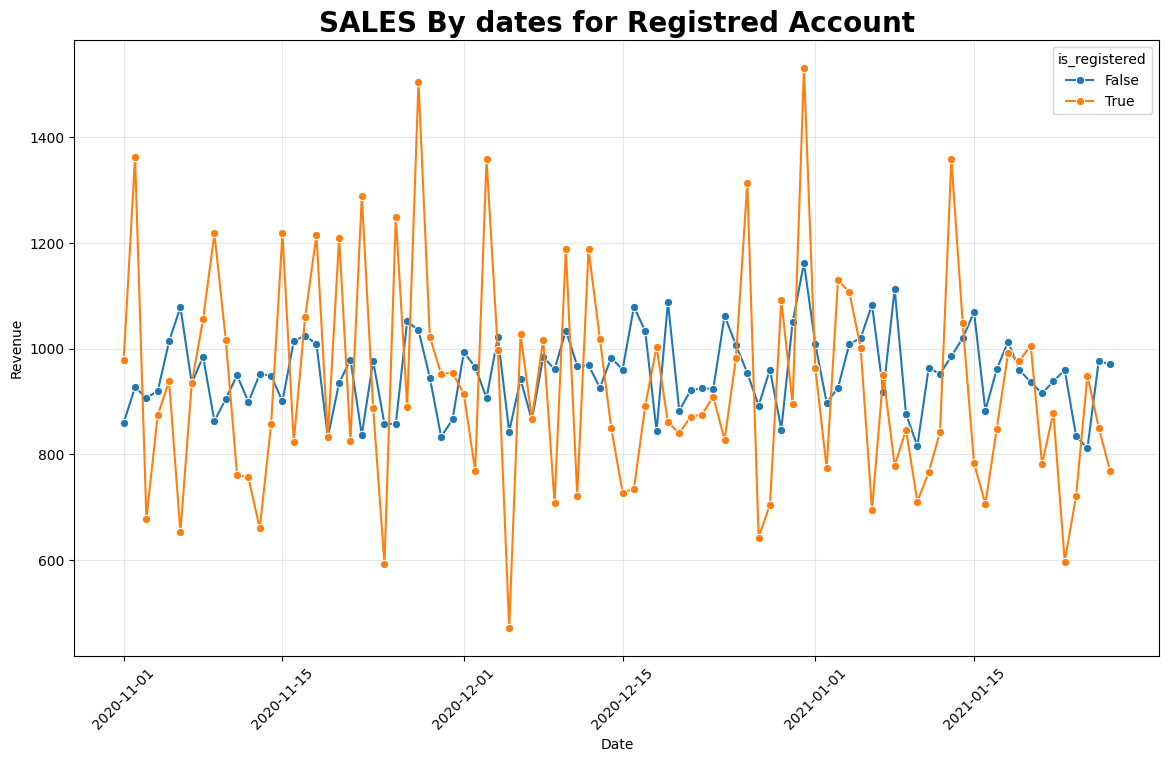

In [59]:
plot_data = df[["date", "price", "is_registered"]].copy()
plt.figure(figsize=(14,8))

sns.lineplot(
    data=plot_data,
    x="date",
    y="price",
    hue="is_registered",
    marker="o",
    errorbar=None
)
plt.title("SALES By dates for Registred Account",fontsize=20, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

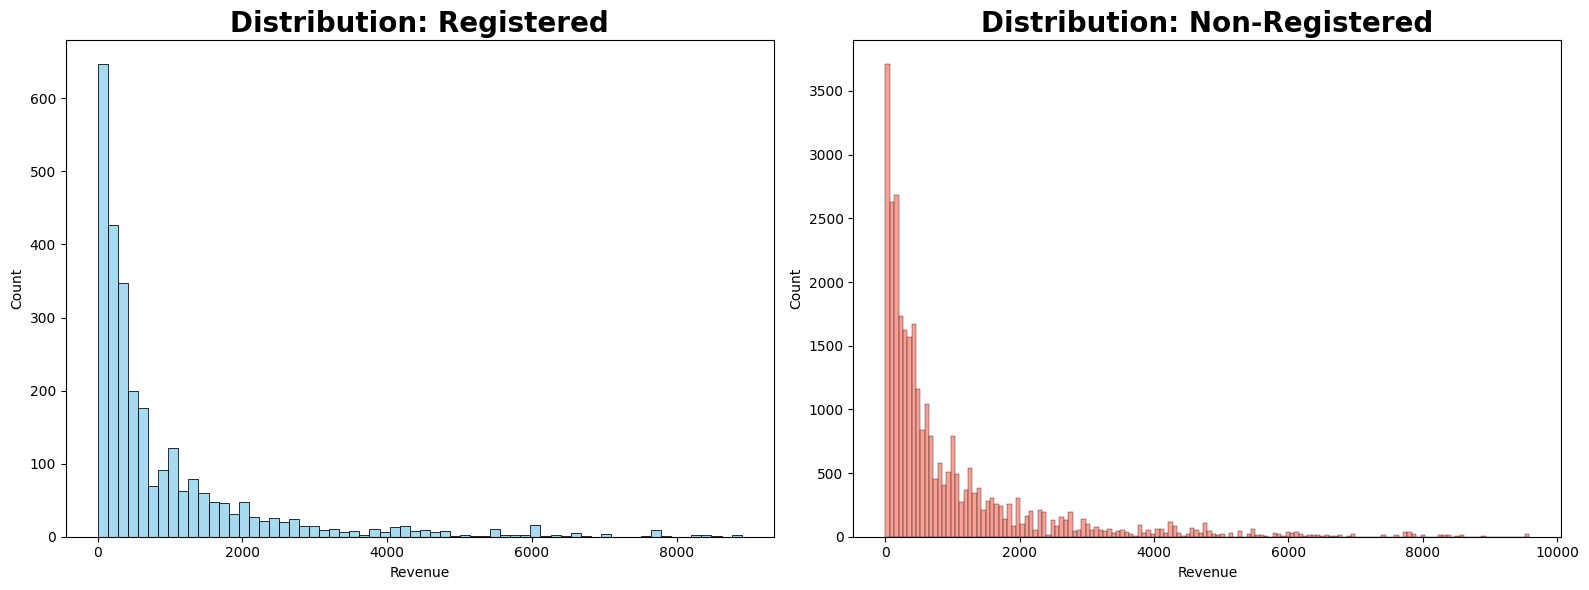

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(registered_sales, kde=False, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution: Registered",fontsize=20, fontweight="bold")
axes[0].set_xlabel("Revenue")
sns.histplot(unregistered_sales, kde=False, ax=axes[1], color="salmon")
axes[1].set_title("Distribution: Non-Registered",fontsize=20, fontweight="bold")
axes[1].set_xlabel("Revenue")
plt.tight_layout()
plt.show()

It is noticeable here that the distributions in both cases are not normal. The data are not clustered around the mean. The distribution is similar to an exponential with a long "tail", where the largest values ​​​​are concentrated, which decrease from left to right.
Since the data do not have a symmetrical "bell" shape (non-normal distribution), I will use the Mann-Whitney U-test in the future.
Both histograms have a peak on the left and a long "tail" on the right.
This indicates that a huge number of orders are concentrated in the low price zone. The higher the price, the fewer orders. However, these single expensive orders (from 6000 to 10000) form a significant part of the revenue.

In [61]:
from scipy.stats import mannwhitneyu
reg_clean = registered_sales.dropna()
unreg_clean = unregistered_sales.dropna()
u_stat, p_value = mannwhitneyu(reg_clean, unreg_clean)
print(f" Registered: {len(reg_clean)}")
print(f" Unregistered: {len(unreg_clean)}")
print(f"P-value: {p_value}")

 Registered: 2781
 Unregistered: 30757
P-value: 0.041590896614016215


The result is statistically significant. After all, p_value<0.05. Therefore, we can reject the null hypothesis that the groups are the same. Registration matters: There is a real statistical difference in how registered and unregistered users spend money. This is not a coincidence.

In [62]:
channel_count_session=df.pivot_table(index="channel",values="ga_session_id",aggfunc="count").reset_index()
channel_count_session.columns = ["Channel", "Session_Count"]
print(channel_count_session)

          Channel  Session_Count
0          Direct          81382
1  Organic Search         124425
2     Paid Search          94341
3   Social Search          27914
4       Undefined          21483


/tmp/ipykernel_8343/4293487624.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_count_session.sort_values(by="Session_Count", ascending=False),x="Channel", y="Session_Count", palette="viridis")


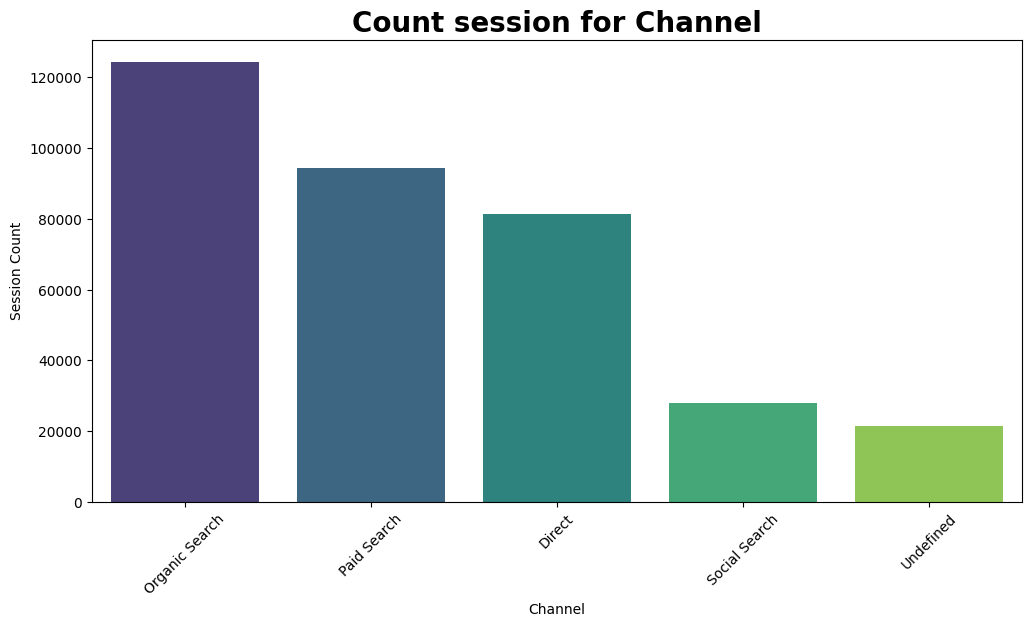

In [63]:
plt.figure(figsize=(12, 6))
sns.barplot(data=channel_count_session.sort_values(by="Session_Count", ascending=False),x="Channel", y="Session_Count", palette="viridis")
plt.title("Count session for Channel",fontsize=20, fontweight="bold")
plt.xlabel("Channel")
plt.ylabel("Session Count")
plt.xticks(rotation=45)
plt.show()

In [64]:
from scipy.stats import chisquare
stat, p_value = chisquare(channel_count_session["Session_Count"])
print(f"Статистика Хі-квадрат: {stat:.4f}")
print(f"P-value: {p_value}")

Статистика Хі-квадрат: 111705.2756
P-value: 0.0


P-value: 0.0<0.05. This is much smaller than the standard threshold of 0.05. We can reject the null hypothesis of equality of channels. The result is statistically significant at the highest level.

In [65]:
europe_data = df[df["continent"] == "Europe"]
americas_data = df[df["continent"] == "Americas"]
n_europe = len(europe_data)
n_americas = len(americas_data)
organic_europe = len(europe_data[europe_data["channel"] == "Organic Search"])
organic_americas = len(americas_data[americas_data["channel"] == "Organic Search"])

print(f"Europe: {organic_europe} Organic.Total: {n_europe} sessions. ({(organic_europe/n_europe)*100}%)")
print(f"Americas: {organic_americas} Organic.Total:  {n_americas} sessions. ({(organic_americas/n_americas)*100}%)")

Europe: 23195 Organic.Total: 65135 sessions. (35.610654793889616%)
Americas: 68671 Organic.Total:  193179 sessions. (35.54785975701293%)


In [66]:
from statsmodels.stats.proportion import proportions_ztest
organic = [organic_europe, organic_americas]
total = [n_europe, n_americas]

z_stat, p_value = proportions_ztest(organic,total)
print(f"P-value: {p_value}")

P-value: 0.7721879690501752


P_value=0.7, which is greater than 0.05. Therefore, the results are not statistically significant. Despite possible differences in percentages, they are most likely due to chance rather than real differences in market behavior.

# General conclusion:

After analyzing the sales analytics of the online store, several main points can be highlighted. The main market is America, there are more than 12,000 accounts. The American continent (due to the USA) is significantly ahead of Asia and Europe both in terms of revenue and the number of orders. India and Canada take second and third places. The main profit is brought by the category "Sofas & armchairs", which is the leader ($8.4 million). There are also high indicators in the categories "Chairs" and "Beds". Children's furniture and bar furniture bring the least revenue. In addition to sofas, chairs and beds are actively bought. Wardrobes, bookshelves have a stable average indicator. Office desks and children's furniture are bought much less often.

Most purchases are made from desktops (59%). Mobile devices occupy 38.7%. The most popular browser is Chrome (68.3%). Among operating systems, the Web platform and Windows bring the most revenue.

Organic Search is the main source of traffic. Paid Search and Direct also demonstrate high efficiency. Social Search has the least impact on the indicators so far.

You can see a steady growth in revenue from the beginning of the year (January) to May. In June and July, there is a small plateau, followed by a sharp jump in August, where revenue reaches a peak.

The number of subscriptions consistently exceeds the number of unsubscribes. This is a positive indicator, indicating that the customer base is growing. The graph shows that the increase in subscriptions is accompanied by an increase in unsubscribes, which is logical. There is a noticeable increase in activity on weekends or in certain weeks of the month, I can assume that these are pre-holiday or payday days. There is a strong positive correlation between the number of sessions and the number of subscriptions. Which means that the more traffic on the site, the more subscriptions.

The graph shows a characteristic spike in November and December, and there is also an increase in January. At this time, the number of sessions on the site increases by almost 1.5–2 times compared to the summer months. This indicates the seasonality of sales in winter.